KOMPARASI METODE SEGMENTASI UNTUK EKSTRAKSI OBJEK

HASIL : Bimodal
----------------------------------------------------------------------
Metode                 IoU        Dice       Accuracy   Precision  Recall     Time      
------------------------------------------------------------------------------------------
Global                 1.000      1.000      1.000      1.000      1.000      0.00045   
Otsu                   0.922      0.959      0.996      0.922      1.000      0.00027   
Adaptive Mean          0.037      0.072      0.061      0.038      0.734      0.00081   
Adaptive Gaussian      0.036      0.069      0.055      0.036      0.710      0.00079   
Region Growing         0.000      0.000      0.008      0.000      0.000      0.00000   
Watershed              0.834      0.910      0.991      0.880      0.942      0.00000   
Connected Component    0.922      0.959      0.996      0.922      1.000      0.00000   


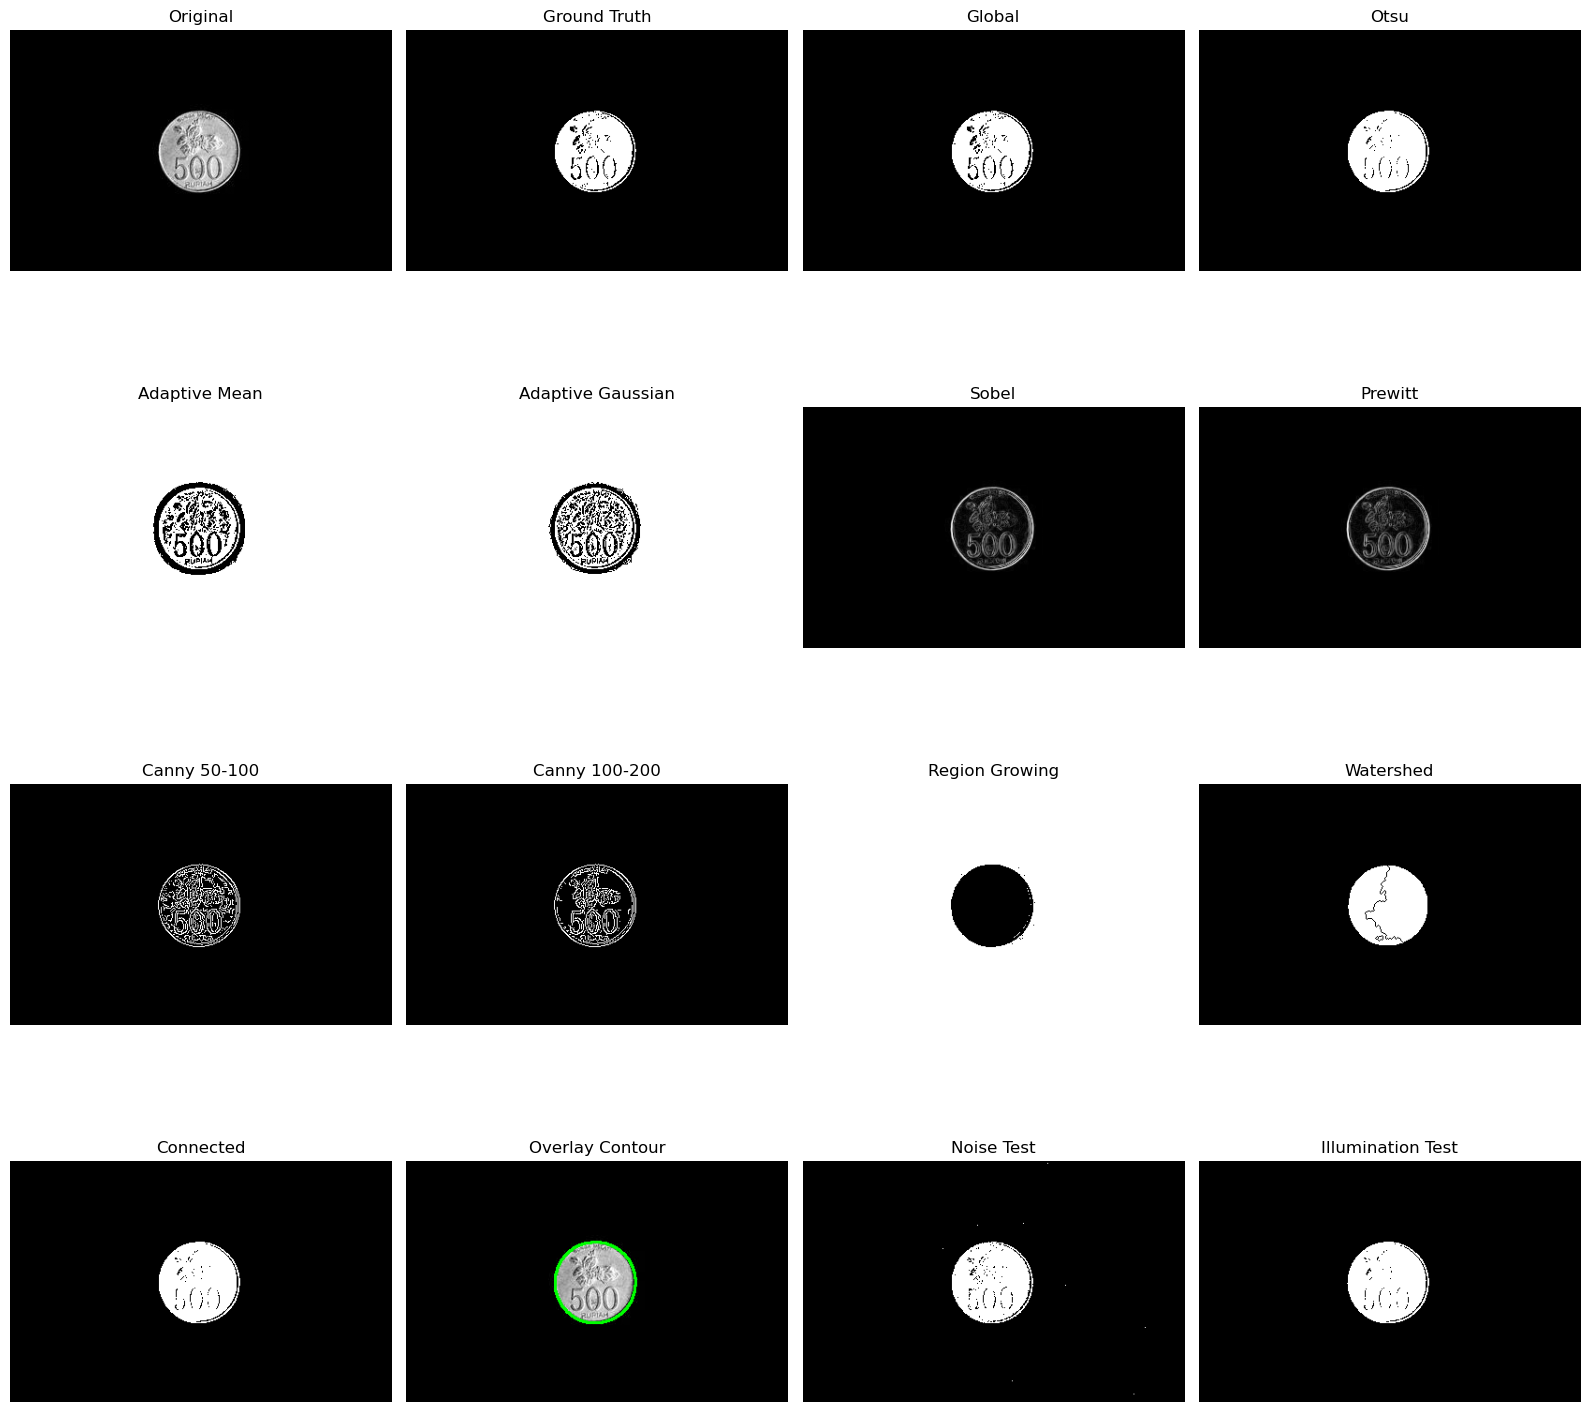


HASIL : Uneven Illumination
----------------------------------------------------------------------
Metode                 IoU        Dice       Accuracy   Precision  Recall     Time      
------------------------------------------------------------------------------------------
Global                 1.000      1.000      1.000      1.000      1.000      0.00194   
Otsu                   0.203      0.337      0.898      0.203      1.000      0.00989   
Adaptive Mean          0.023      0.046      0.267      0.024      0.675      0.01729   
Adaptive Gaussian      0.023      0.044      0.235      0.023      0.683      0.03675   
Region Growing         0.000      0.000      0.194      0.000      0.000      0.00000   
Watershed              0.375      0.546      0.960      0.386      0.932      0.00000   
Connected Component    0.203      0.337      0.898      0.203      1.000      0.00000   


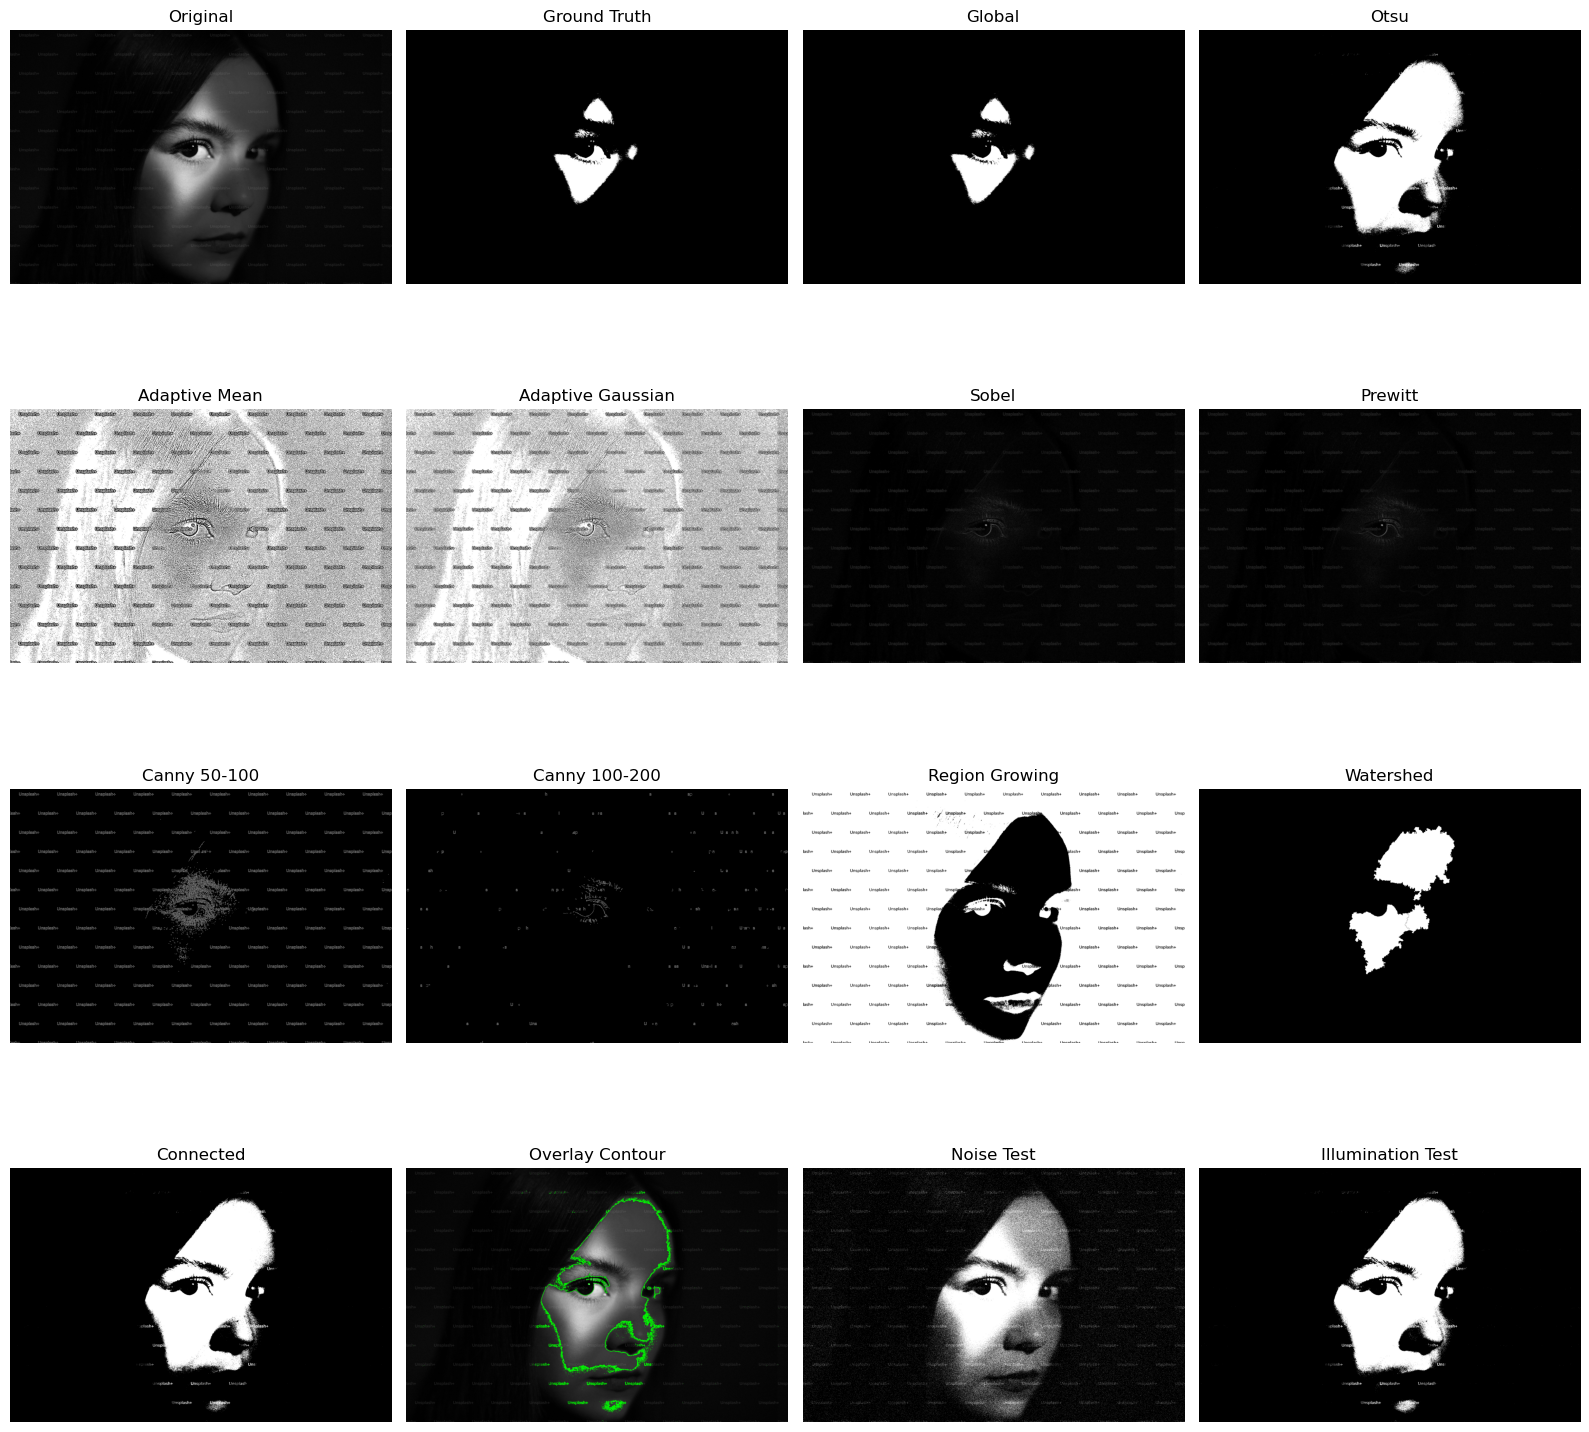


HASIL : Overlapping Object
----------------------------------------------------------------------
Metode                 IoU        Dice       Accuracy   Precision  Recall     Time      
------------------------------------------------------------------------------------------
Global                 1.000      1.000      1.000      1.000      1.000      0.00023   
Otsu                   1.000      1.000      1.000      1.000      1.000      0.00039   
Adaptive Mean          0.151      0.262      0.342      0.162      0.682      0.00116   
Adaptive Gaussian      0.151      0.262      0.320      0.161      0.702      0.00289   
Region Growing         0.000      0.000      0.464      0.000      0.000      0.00000   
Watershed              0.584      0.738      0.928      0.992      0.587      0.00000   
Connected Component    1.000      1.000      1.000      1.000      1.000      0.00000   


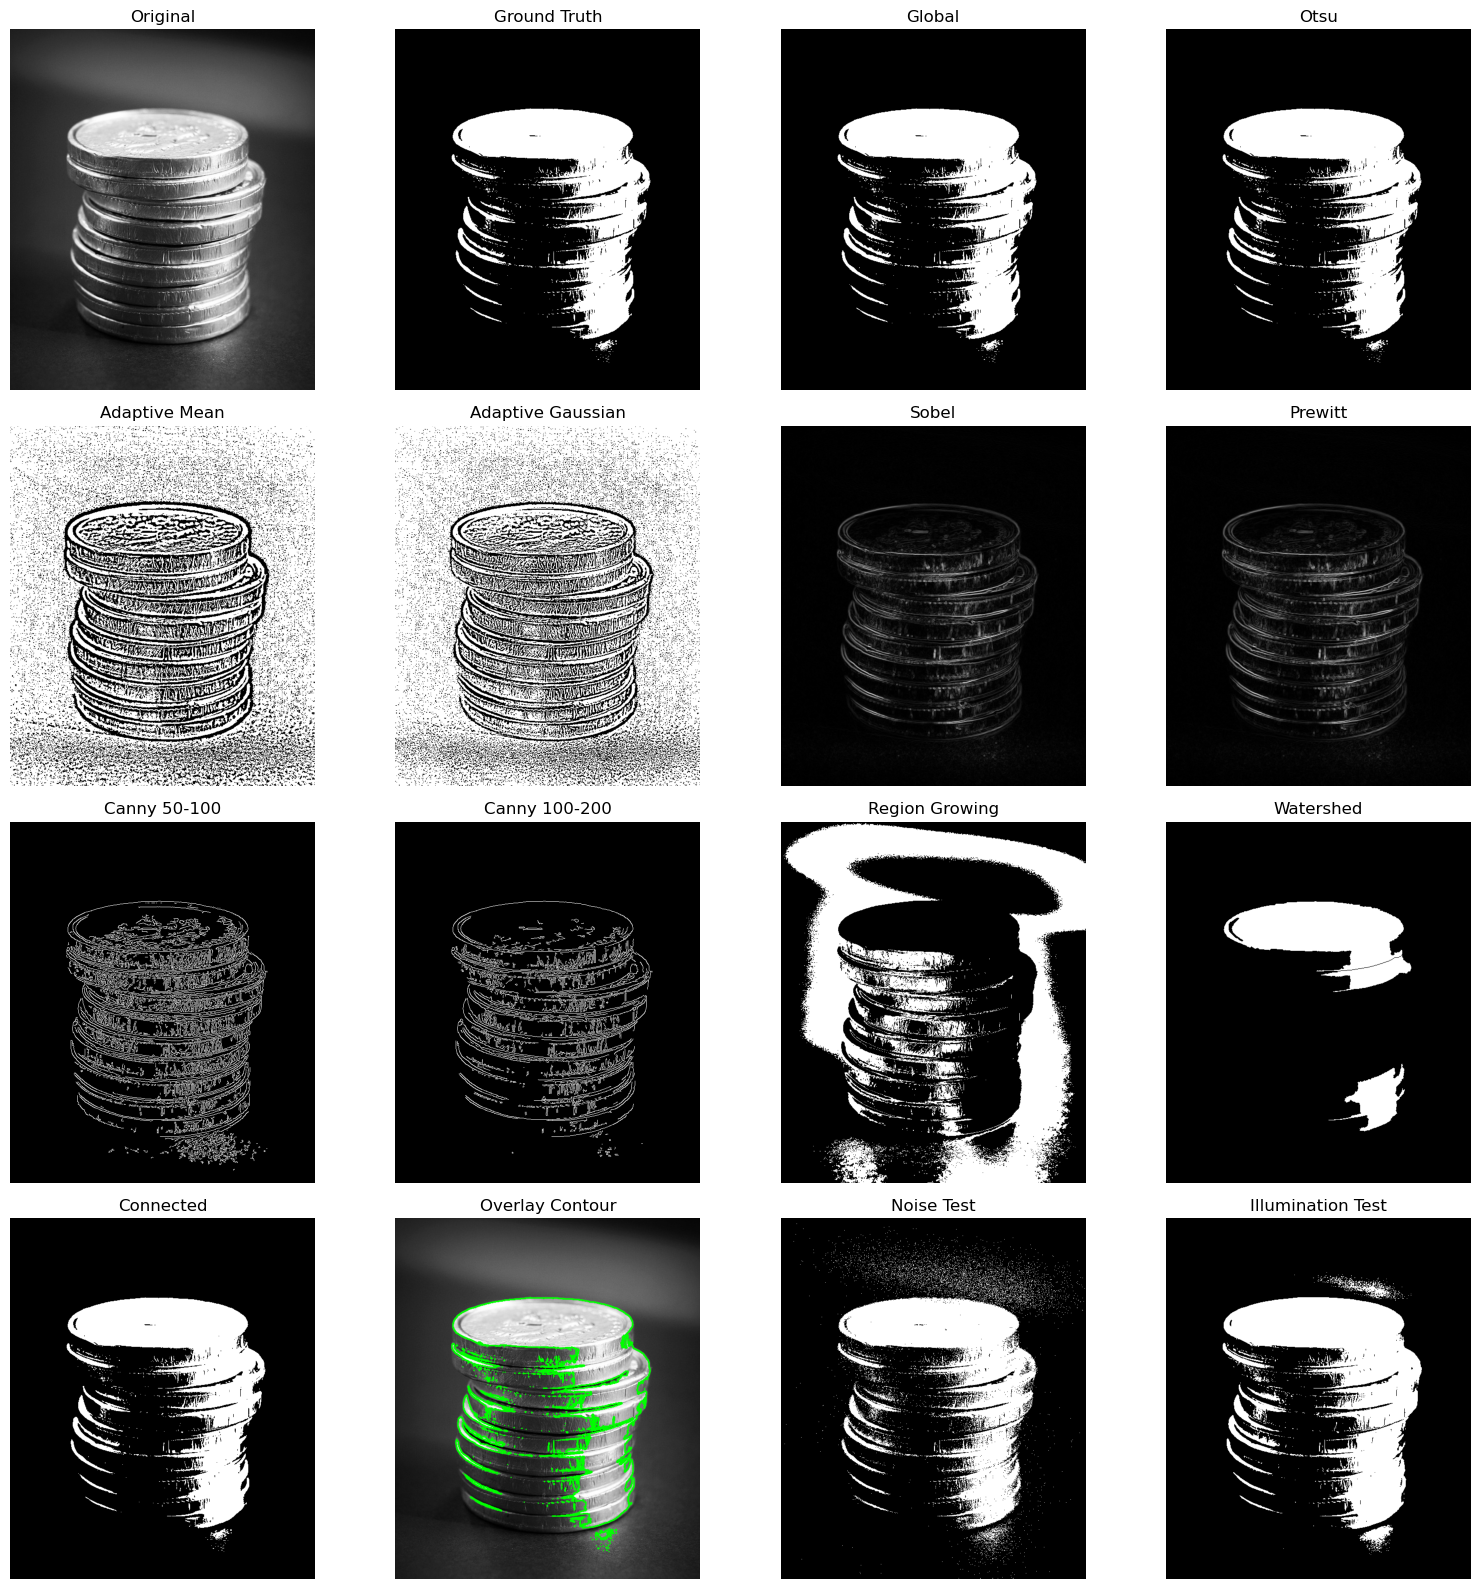

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time

print("KOMPARASI METODE SEGMENTASI UNTUK EKSTRAKSI OBJEK")
print("=" * 70)

# =========================================================
# 1. MENYIAPKAN 3 CITRA DENGAN KARAKTERISTIK BERBEDA
# =========================================================

# 1.1 Citra bimodal
img1 = cv2.imread("bimodal.jpeg", 0)
_, gt1 = cv2.threshold(img1, 127, 255, cv2.THRESH_BINARY)

# 1.2 Citra iluminasi tidak merata
img2 = cv2.imread("iluminasi_tidak_merata.jpg", 0)
_, gt2 = cv2.threshold(img2, 127, 255, cv2.THRESH_BINARY)

# 1.3 Citra objek overlapping
img3 = cv2.imread("overlapping.jpg", 0)
_, gt3 = cv2.threshold(img3, 127, 255, cv2.THRESH_BINARY)

images = [
    ("Bimodal", img1, gt1),
    ("Uneven Illumination", img2, gt2),
    ("Overlapping Object", img3, gt3)
]

# =========================================================
# 2. IMPLEMENTASI METODE THRESHOLDING
# =========================================================

def global_threshold(image):

    _, result = cv2.threshold(
        image,
        127,
        255,
        cv2.THRESH_BINARY
    )

    return result

def otsu_threshold(image):

    _, result = cv2.threshold(
        image,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return result

def adaptive_mean_threshold(image):

    result = cv2.adaptiveThreshold(
        image,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    return result

def adaptive_gaussian_threshold(image):

    result = cv2.adaptiveThreshold(
        image,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    return result

# =========================================================
# 3. IMPLEMENTASI EDGE DETECTION
# =========================================================

def sobel_detection(image):

    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1)

    magnitude = np.sqrt(sobelx**2 + sobely**2)

    magnitude = cv2.normalize(
        magnitude,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    orientation = np.arctan2(sobely, sobelx)

    return magnitude, orientation

def prewitt_detection(image):

    kernelx = np.array([
        [1,0,-1],
        [1,0,-1],
        [1,0,-1]
    ])

    kernely = np.array([
        [1,1,1],
        [0,0,0],
        [-1,-1,-1]
    ])

    px = cv2.filter2D(image.astype(np.float32), -1, kernelx)
    py = cv2.filter2D(image.astype(np.float32), -1, kernely)

    result = np.sqrt(px**2 + py**2)

    result = cv2.normalize(
        result,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return result

def canny_detection(image, low, high):

    result = cv2.Canny(image, low, high)

    return result

# =========================================================
# 4. IMPLEMENTASI REGION-BASED SEGMENTATION
# =========================================================

def region_growing(image, seed):

    result = np.zeros_like(image)

    h, w = image.shape

    for i in range(h):
        for j in range(w):

            if abs(
                int(image[i,j]) -
                int(image[seed])
            ) < 20:

                result[i,j] = 255

    return result

def watershed_segmentation(image, binary):

    kernel = np.ones((3,3), np.uint8)

    sure_bg = cv2.dilate(binary, kernel, iterations=2)

    dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)

    _, sure_fg = cv2.threshold(
        dist,
        0.5 * dist.max(),
        255,
        0
    )

    sure_fg = np.uint8(sure_fg)

    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)

    markers = markers + 1

    markers[unknown == 255] = 0

    color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    markers = cv2.watershed(color, markers)

    result = np.zeros_like(image)

    result[markers > 1] = 255

    return result

def connected_component(binary):

    num_labels, labels = cv2.connectedComponents(binary)

    result = np.zeros_like(binary)

    for i in range(1, num_labels):

        result[labels == i] = 255

    return result

# =========================================================
# 5. EVALUASI KOMPREHENSIF
# =========================================================

def calculate_metrics(result, gt):

    result = (result > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)

    tp = np.sum((result == 1) & (gt == 1))
    fp = np.sum((result == 1) & (gt == 0))
    fn = np.sum((result == 0) & (gt == 1))
    tn = np.sum((result == 0) & (gt == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision = tp / (tp + fp + 1e-10)

    recall = tp / (tp + fn + 1e-10)

    dice = (2 * tp) / ((2 * tp) + fp + fn + 1e-10)

    iou = tp / (tp + fp + fn + 1e-10)

    return accuracy, precision, recall, dice, iou

# =========================================================
# PROSES SEMUA CITRA
# =========================================================

for name, image, gt in images:

    print("\nHASIL :", name)
    print("-" * 70)

    # -----------------------------------------------------
    # 2.1 Global Thresholding

    start = time.time()

    global_result = global_threshold(image)

    time_global = time.time() - start

    # -----------------------------------------------------
    # 2.2 Otsu Thresholding

    start = time.time()

    otsu_result = otsu_threshold(image)

    time_otsu = time.time() - start

    # -----------------------------------------------------
    # 2.3 Adaptive Mean Thresholding

    start = time.time()

    adaptive_mean = adaptive_mean_threshold(image)

    time_mean = time.time() - start

    # -----------------------------------------------------
    # 2.4 Adaptive Gaussian Thresholding

    start = time.time()

    adaptive_gaussian = adaptive_gaussian_threshold(image)

    time_gaussian = time.time() - start

    # -----------------------------------------------------
    # 3.1 Sobel Edge Detection

    sobel_result, orientation = sobel_detection(image)

    # -----------------------------------------------------
    # 3.2 Prewitt Edge Detection

    prewitt_result = prewitt_detection(image)

    # -----------------------------------------------------
    # 3.3 Canny Edge Detection

    canny1 = canny_detection(image, 50, 100)

    canny2 = canny_detection(image, 100, 200)

    # -----------------------------------------------------
    # 4.1 Region Growing

    region_result = region_growing(image, (120,120))

    # -----------------------------------------------------
    # 4.2 Watershed Segmentation

    watershed_result = watershed_segmentation(
        image,
        otsu_result
    )

    # -----------------------------------------------------
    # 4.3 Connected Components Analysis

    connected_result = connected_component(
        otsu_result
    )

    # =====================================================
    # 5.1 TABEL METRIK
    # =====================================================

    methods = [
        ("Global", global_result, time_global),
        ("Otsu", otsu_result, time_otsu),
        ("Adaptive Mean", adaptive_mean, time_mean),
        ("Adaptive Gaussian", adaptive_gaussian, time_gaussian),
        ("Region Growing", region_result, 0),
        ("Watershed", watershed_result, 0),
        ("Connected Component", connected_result, 0)
    ]

    print(f"{'Metode':<22} {'IoU':<10} {'Dice':<10} "
          f"{'Accuracy':<10} {'Precision':<10} "
          f"{'Recall':<10} {'Time':<10}")

    print("-" * 90)

    for method, result, runtime in methods:

        acc, prec, rec, dice, iou = calculate_metrics(
            result,
            gt
        )

        print(f"{method:<22} "
              f"{iou:<10.3f} "
              f"{dice:<10.3f} "
              f"{acc:<10.3f} "
              f"{prec:<10.3f} "
              f"{rec:<10.3f} "
              f"{runtime:<10.5f}")

    # =====================================================
    # 5.2 VISUALISASI HASIL
    # =====================================================

    fig, axes = plt.subplots(4,4, figsize=(16,16))

    axes[0,0].imshow(image, cmap='gray')
    axes[0,0].set_title("Original")

    axes[0,1].imshow(gt, cmap='gray')
    axes[0,1].set_title("Ground Truth")

    axes[0,2].imshow(global_result, cmap='gray')
    axes[0,2].set_title("Global")

    axes[0,3].imshow(otsu_result, cmap='gray')
    axes[0,3].set_title("Otsu")

    axes[1,0].imshow(adaptive_mean, cmap='gray')
    axes[1,0].set_title("Adaptive Mean")

    axes[1,1].imshow(adaptive_gaussian, cmap='gray')
    axes[1,1].set_title("Adaptive Gaussian")

    axes[1,2].imshow(sobel_result, cmap='gray')
    axes[1,2].set_title("Sobel")

    axes[1,3].imshow(prewitt_result, cmap='gray')
    axes[1,3].set_title("Prewitt")

    axes[2,0].imshow(canny1, cmap='gray')
    axes[2,0].set_title("Canny 50-100")

    axes[2,1].imshow(canny2, cmap='gray')
    axes[2,1].set_title("Canny 100-200")

    axes[2,2].imshow(region_result, cmap='gray')
    axes[2,2].set_title("Region Growing")

    axes[2,3].imshow(watershed_result, cmap='gray')
    axes[2,3].set_title("Watershed")

    axes[3,0].imshow(connected_result, cmap='gray')
    axes[3,0].set_title("Connected")

    overlay = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    contours, _ = cv2.findContours(
        otsu_result,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        overlay,
        contours,
        -1,
        (0,255,0),
        2
    )

    axes[3,1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[3,1].set_title("Overlay Contour")

    noise = np.random.normal(0, 25, image.shape)

    noisy = image + noise

    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    noisy_otsu = otsu_threshold(noisy)

    axes[3,2].imshow(noisy_otsu, cmap='gray')
    axes[3,2].set_title("Noise Test")

    bright = cv2.convertScaleAbs(
        image,
        alpha=1.2,
        beta=50
    )

    bright_otsu = otsu_threshold(bright)

    axes[3,3].imshow(bright_otsu, cmap='gray')
    axes[3,3].set_title("Illumination Test")

    for ax in axes.ravel():
        ax.axis("off")

    plt.tight_layout()
    plt.show()